<div style="font-family:Arial; background-color:#f6f7f9; padding:30px; border-radius:10px;">

<h1 style="color:#1f4e79; text-align:center; margin-bottom:5px;">
Modélisation Générative du Risque Climatique
</h1>

<h3 style="color:#2563eb; text-align:center; margin-top:0;">
Application à l’Indice de Haines — Potentiel de Feux Extrêmes
</h3>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h2 style="color:#1f4e79;">1. Introduction</h2>

<h3 style="color:#2e75b6;">1.1 Contexte physique et climatique</h3>

<p>
L’intensification des incendies de forêt constitue l’une des manifestations les plus critiques du changement climatique.
Au-delà de leur fréquence, c’est leur <b>caractère extrême et imprévisible</b> qui pose aujourd’hui un défi majeur aux modèles de risque.
Ces événements, souvent qualifiés de <i>méga-feux</i>, échappent aux dynamiques classiques en développant leurs propres mécanismes atmosphériques.
</p>

<p>
Dans ce contexte, l’<b>Indice de Haines</b> s’impose comme un indicateur clé.
Il ne se limite pas aux conditions de surface, mais capture les propriétés de la basse atmosphère (≈ 1500m – 3000m), essentielles à la propagation verticale des feux.
</p>

<ul>
<li><b>Stabilité atmosphérique :</b> capacité de l’air à favoriser l’ascension des masses chaudes</li>
<li><b>Sécheresse en altitude :</b> déficit d’humidité facilitant l’embrasement</li>
</ul>

<p style="font-family:monospace; font-size:15px; color:#333;">
H = (T850 − T700) + (T850 − DP850)
</p>

<p>
Cet indice permet ainsi d’identifier des configurations propices à des dynamiques de feu auto-entretenues.
</p>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h3 style="color:#2e75b6;">1.2 Enjeux pour l’assurance</h3>

<p>
Pour les assureurs, la compréhension fine de ces dynamiques est essentielle.
Les pertes associées aux événements extrêmes sont caractérisées par une forte concentration et une faible fréquence.
</p>

<ul>
<li>Anticipation des événements de forte sévérité</li>
<li>Amélioration de la sélection des risques</li>
<li>Dimensionnement des réserves et du capital économique</li>
</ul>

<p>
L’Indice de Haines constitue ainsi un outil complémentaire aux modèles traditionnels, notamment pour l’analyse des scénarios extrêmes.
</p>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h2 style="color:#1f4e79;">2. Problématique</h2>

<h3 style="color:#2e75b6;">2.1 Limites des données historiques</h3>

<p>
Les bases de données climatiques modernes, telles que ERA5, offrent une couverture riche mais limitée dans le temps.
Cet horizon temporel reste insuffisant pour capturer des événements rares, mais pourtant plausibles physiquement.
</p>

<p>
Les approches statistiques classiques tendent à sous-estimer les <b>queues de distribution</b>, conduisant à une mauvaise évaluation du risque extrême.
</p>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h3 style="color:#2e75b6;">2.2 Question de recherche</h3>

<p style="font-style:italic; color:#1f4e79;">
Dans quelle mesure les modèles d’IA générative (VAE, GAN) permettent-ils de simuler des scénarios climatiques extrêmes, réalistes et cohérents, afin d’améliorer la modélisation du risque et la tarification en assurance ?
</p>

<p>
L’objectif est de dépasser les limites de l’historique observé en générant des données synthétiques capables de :
</p>

<ul>
<li>reproduire la structure statistique réelle</li>
<li>capturer les événements extrêmes</li>
<li>enrichir les analyses de stress et de solvabilité</li>
</ul>

</div>

In [1]:
import sys
sys.path.insert(0, "..")


In [2]:
import config
config.set_seed()

<div style="font-family:Arial; line-height:1.5;">
Nous procédons au chargement des données ERA5 afin de construire l’indice de Haines à partir des variables atmosphériques.
Les températures aux niveaux 850 hPa et 700 hPa ainsi que l’humidité relative sont extraites.
Une approximation de la dépression du point de rosée est ensuite calculée, permettant de dériver l’indice final.
Une vérification des dimensions et des premières valeurs est réalisée afin de valider la cohérence des données.
</div>

In [3]:
from src.data_loader import load_haines

ds, haines_index = load_haines("./data/haines_data.nc")

Dimensions de l'indice : ('valid_time', 'latitude', 'longitude')
Aperçu des valeurs : [16.769245 13.93526  10.052057  7.256354  6.234088]


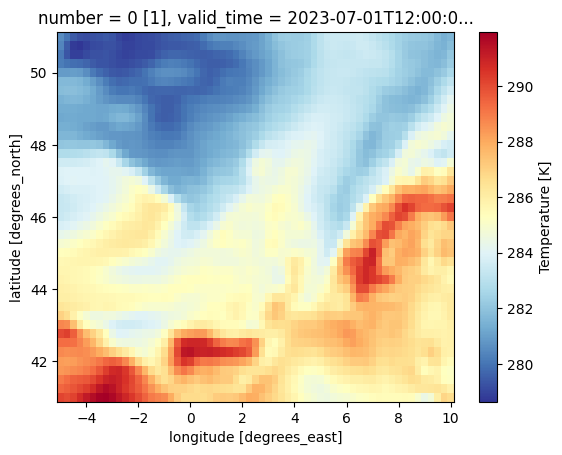

In [4]:
ds.t.sel(pressure_level=850, valid_time="2023-07-01T12:00:00").plot(cmap="RdYlBu_r")

<div style="font-family:Arial; line-height:1.5; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
Nous observons une cartographie spatiale de la température au niveau 850 hPa sur la zone étudiée.
La structure des données est cohérente avec une grille géographique classique (temps, latitude, longitude), ce qui valide le bon chargement du cube ERA5.
</p>

<p>
Le champ thermique met en évidence un <b>gradient nord-sud marqué</b> :
les températures les plus faibles apparaissent au nord (zones bleues), tandis que le sud présente des valeurs plus élevées (zones rouges).
Cette configuration est physiquement cohérente avec la dynamique atmosphérique estivale en Europe.
</p>

<p>
La présence de structures localisées suggère des <b>zones de chaleur plus intenses</b>, pouvant favoriser des conditions propices aux feux
si elles sont associées à une atmosphère sèche et instable.
</p>

<p>
Ces éléments confirment que les variables utilisées pour construire l’indice de Haines capturent des <b>variations spatiales réalistes</b>,
ce qui constitue une base solide pour la modélisation générative.
</p>

</div>

<div style="font-family:Arial; line-height:1.5;">
<b>Objectif :</b> transformer l’indice de Haines (xarray) en DataFrame pour l’analyse.
On convertit les données en format tabulaire, on supprime les valeurs manquantes, puis on ajoute une catégorisation du risque.
Cette étape permet de préparer les données pour des analyses statistiques ou des modèles de machine learning.
</div>

In [5]:
from src.preprocessing import build_dataframe

df = build_dataframe(haines_index)
print(df.head())


           valid_time  latitude  longitude  number expver  pressure_level  \
0 2023-07-01 12:00:00      51.0      -5.00       0   0001           850.0   
1 2023-07-01 12:00:00      51.0      -4.75       0   0001           850.0   
2 2023-07-01 12:00:00      51.0      -4.50       0   0001           850.0   
3 2023-07-01 12:00:00      51.0      -4.25       0   0001           850.0   
4 2023-07-01 12:00:00      51.0      -4.00       0   0001           850.0   

   haines_index risk_level  
0     16.769245       High  
1     13.935260       High  
2     10.052057       High  
3      7.256354   Moderate  
4      6.234088        Low  


In [6]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77531 entries, 0 to 77530
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   valid_time      77531 non-null  datetime64[ns]
 1   latitude        77531 non-null  float64       
 2   longitude       77531 non-null  float64       
 3   number          77531 non-null  int64         
 4   expver          77531 non-null  object        
 5   pressure_level  77531 non-null  float64       
 6   haines_index    77531 non-null  float32       
 7   risk_level      77531 non-null  object        
dtypes: datetime64[ns](1), float32(1), float64(3), int64(1), object(2)
memory usage: 4.4+ MB
None
valid_time        0
latitude          0
longitude         0
number            0
expver            0
pressure_level    0
haines_index      0
risk_level        0
dtype: int64


<div style="font-family:Arial; line-height:1.5;">
Nous calculons les statistiques descriptives de l’indice (moyenne, dispersion) ainsi que les indicateurs de forme de la distribution (asymétrie et aplatissement).
La répartition des niveaux de risque est ensuite analysée afin d’obtenir une lecture directe de l’exposition et de la fréquence des situations critiques.
</div>

In [7]:
from src.preprocessing import print_stats

print_stats(df)
print(df["risk_level"].value_counts(normalize=True) * 100)

Structure Statistique de l'Indice :
- Skewness (Asymétrie)     : 0.388
- Kurtosis (Aplatissement) : -0.443
- Shapiro-Wilk (p-value)   : 0.00000
risk_level
High        82.534728
Moderate     8.991242
Low          8.474030
Name: proportion, dtype: float64


<div style="font-family:Arial; line-height:1.5; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
Nous observons une valeur moyenne de l’indice de Haines autour de <b>15.17</b>, avec une dispersion relativement modérée (écart-type de 6.42).
Cela indique une variabilité significative des conditions atmosphériques, sans être dominée par des fluctuations extrêmes.
</p>

<p>
L’asymétrie positive (<b>skewness = 0.39</b>) révèle une distribution légèrement étirée vers les valeurs élevées.
Autrement dit, les situations de forte instabilité atmosphérique existent mais restent moins fréquentes que les conditions normales.
</p>

<p>
La kurtosis négative (<b>-0.44</b>) suggère une distribution relativement aplatie, avec une présence d’extrêmes moins marquée que dans une loi normale.
Cela confirme que les événements très sévères sont rares dans les données historiques, ce qui pose un enjeu direct pour la modélisation du risque extrême.
</p>

<p>
La répartition des niveaux de risque montre une forte dominance de la catégorie <b>High (~82%)</b>, tandis que les niveaux <b>Moderate</b> et <b>Low</b> restent marginaux.
Cette concentration peut traduire un biais de seuil ou une normalisation de l’indice, et devra être prise en compte dans l’interprétation assurantielle.
</p>

<p>
Ces résultats mettent en évidence une distribution globalement stable mais <b>insuffisamment riche en extrêmes</b>,
justifiant l’utilisation de modèles génératifs pour explorer des scénarios plus sévères et améliorer l’évaluation du risque.
</p>

</div>

<div style="font-family:Arial; line-height:1.5;">
Nous procédons ensuite à une analyse visuelle de la distribution de l’indice de Haines.
Un histogramme avec densité permet d’observer la forme globale de la distribution, tandis qu’un boxplot met en évidence la présence d’extrêmes.
La répartition des niveaux de risque est représentée afin de faciliter l’interprétation catégorielle.
Enfin, une relation entre latitude et indice est explorée afin d’identifier un éventuel gradient spatial.
</div>

/Users/violetteseptier/Desktop/gen_IA/generative_ia/src/visualization.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_level', palette=[MAIN_COLOR, DARK_GREY, '#94a3b8'], ax=ax3)
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' no

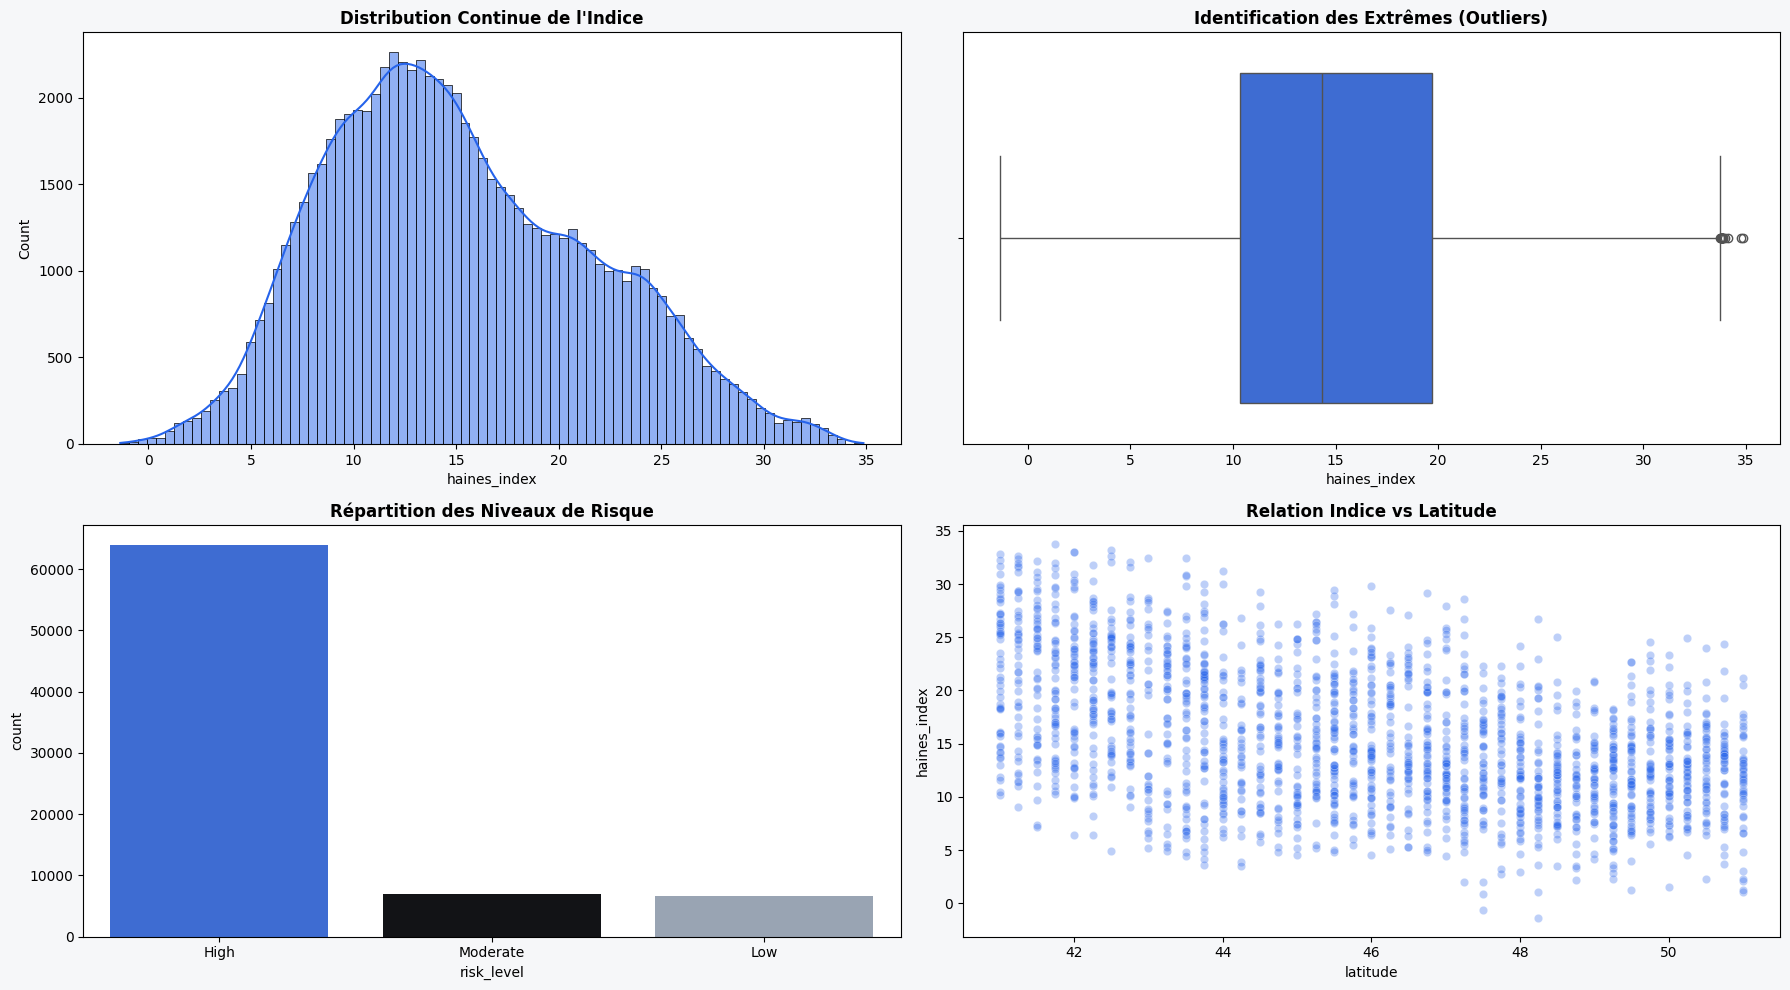

In [8]:
from src.visualization import plot_eda

plot_eda(df)

<div style="font-family:Arial; line-height:1.5;">
Nous structurons l’analyse en trois étapes : visualisation de la distribution, transformation des données et étude statistique approfondie.
La transformation de Box-Cox permet de corriger l’asymétrie, puis une normalisation est appliquée pour préparer les données aux modèles.
Enfin, des indicateurs statistiques et un test de normalité permettent de caractériser précisément la distribution.
</div>

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

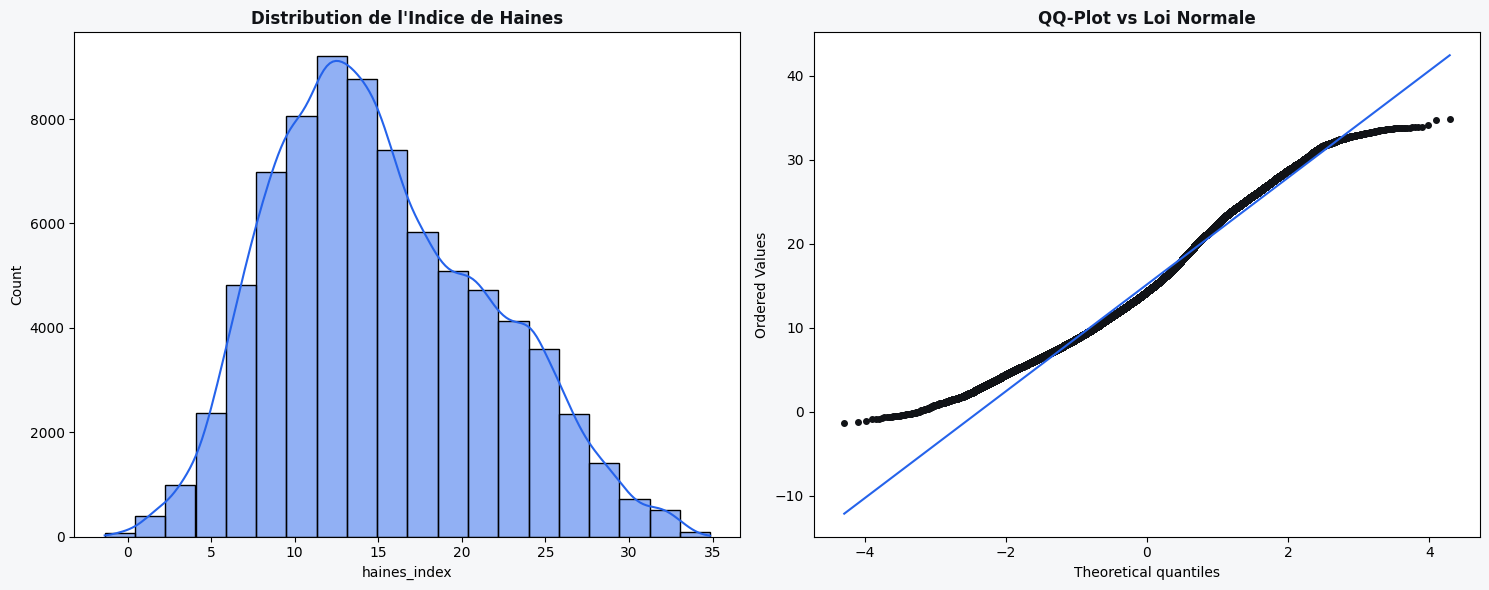

Lambda de Box-Cox : 0.53
DataLoader prêt : 77531 échantillons


In [9]:
from src.preprocessing import fit_transform, make_loader
from src.visualization import plot_preprocessing

plot_preprocessing(df)

df, lmbda, scaler, shift = fit_transform(df)
train_loader, X_train = make_loader(df)


<div style="font-family:Arial; line-height:1.5; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
La distribution de l’indice de Haines présente une forme <b>asymétrique à droite</b>, avec une concentration importante autour des valeurs intermédiaires (≈ 10 à 15) et une décroissance progressive vers les valeurs élevées.
Cette structure confirme la présence d’une majorité de situations modérées, avec quelques occurrences de conditions plus extrêmes.
</p>

<p>
Le boxplot met en évidence plusieurs <b>valeurs extrêmes (outliers)</b> au-delà de 30.
Ces observations, bien que rares, sont particulièrement importantes en contexte assurantiel car elles correspondent aux scénarios de pertes les plus sévères.
</p>

<p>
La transformation de Box-Cox (λ ≈ 0.53) indique une tentative de correction de l’asymétrie, sans pour autant rendre la distribution parfaitement normale.
Cela est confirmé par le test de Shapiro-Wilk (p-value ≈ 0), qui rejette clairement l’hypothèse de normalité.
</p>

<p>
La relation entre l’indice et la latitude suggère un <b>gradient spatial</b> :
les valeurs élevées semblent plus fréquentes à certaines latitudes, traduisant des dynamiques climatiques différenciées.
Cependant, la dispersion reste importante, indiquant que d’autres facteurs (humidité, dynamique locale) jouent un rôle déterminant.
</p>

<p>
Enfin, la forte dominance de la catégorie <b>High</b> dans la répartition des risques confirme que l’indice est majoritairement positionné sur des niveaux élevés,
ce qui peut refléter un biais de construction ou un effet de normalisation.
</p>

<p>
Dans l’ensemble, ces résultats mettent en évidence une distribution <b>non gaussienne, asymétrique et peu riche en extrêmes</b>,
ce qui justifie pleinement le recours à des modèles génératifs pour mieux capturer le risque de queue.
</p>

</div>

# VAE

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:22px; border-radius:10px; border-left:5px solid #2563eb;">

<h1 style="color:#2563eb;">Variational Autoencoder (VAE) — Modélisation probabiliste du Haines Index</h1>

<h2 style="color:#1f4e79;">Objectif</h2>
<p>
Le VAE vise à apprendre une représentation compacte et probabiliste de la distribution du Haines Index afin de générer de nouvelles valeurs réalistes.
</p>

<p style="font-family:monospace; font-size:16px;">
P(x)
</p>

<p>
Contrairement aux GAN, il ne repose pas sur un jeu adversarial mais sur une modélisation explicite de la distribution.
</p>

<hr>

<h2 style="color:#1f4e79;">Principe du modèle</h2>

<p>
Le VAE est composé de deux réseaux :
</p>

<h3 style="color:#2563eb;">Encodeur</h3>
<p>
Projette une donnée x dans un espace latent probabiliste :
</p>

<p style="font-family:monospace; font-size:16px;">
x → (μ, σ²)
</p>

<p>
On obtient une distribution normale :
</p>

<p style="font-family:monospace; font-size:16px;">
z ~ N(μ, σ²)
</p>

<h3 style="color:#2563eb;">Décodeur</h3>
<p>
Reconstruit une donnée à partir du latent :
</p>

<p style="font-family:monospace; font-size:16px;">
x̂ = Decoder(z)
</p>

<hr>

<h2 style="color:#1f4e79;">Fonctionnement</h2>

<ul>
<li>Compression des données dans un espace latent continu</li>
<li>Échantillonnage aléatoire dans cet espace</li>
<li>Reconstruction des données à partir de ce latent</li>
</ul>

<p>
Le modèle apprend une structure globale lissée de la distribution.
</p>

<hr>

<h2 style="color:#1f4e79;">Fonction de perte (ELBO)</h2>

<p style="font-family:monospace; font-size:15px;">
Loss = Reconstruction Loss + KL Divergence
</p>

<ul>
<li><b>Reconstruction :</b> proximité entre x et x̂</li>
<li><b>KLD :</b> régularisation vers une loi normale N(0,1)</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Lecture des résultats</h2>

<ul>
<li>Convergence rapide et stable</li>
<li>Distribution générée très lissée</li>
<li>Max simulé : <b>14.63</b> vs réel <b>34.85</b></li>
<li>VaR fortement sous-estimée</li>
</ul>

<p>
Le modèle capture la moyenne mais échoue à reproduire les extrêmes.
</p>

<hr>

<h2 style="color:#1f4e79;">Limites</h2>

<ul>
<li>Lissage excessif (effet "moyenne")</li>
<li>Incapacité à modéliser les queues de distribution</li>
<li>Sous-estimation du risque extrême</li>
</ul>

<p>
Le VAE est donc adapté à la modélisation globale, mais inadapté pour une application assurantielle nécessitant une bonne représentation des événements rares.
</p>

</div>

Entraînement VAE (10 époques)...


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

  Époque 10/10 | Loss: 0.023821
Entraînement VAE terminé.


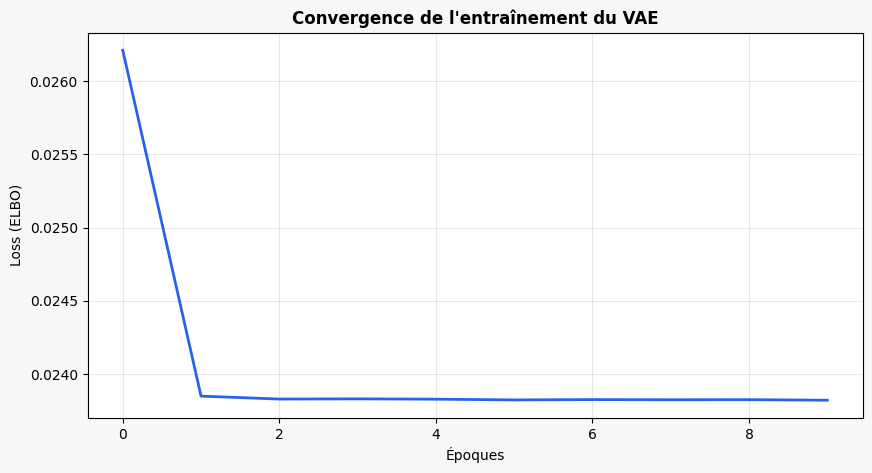

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

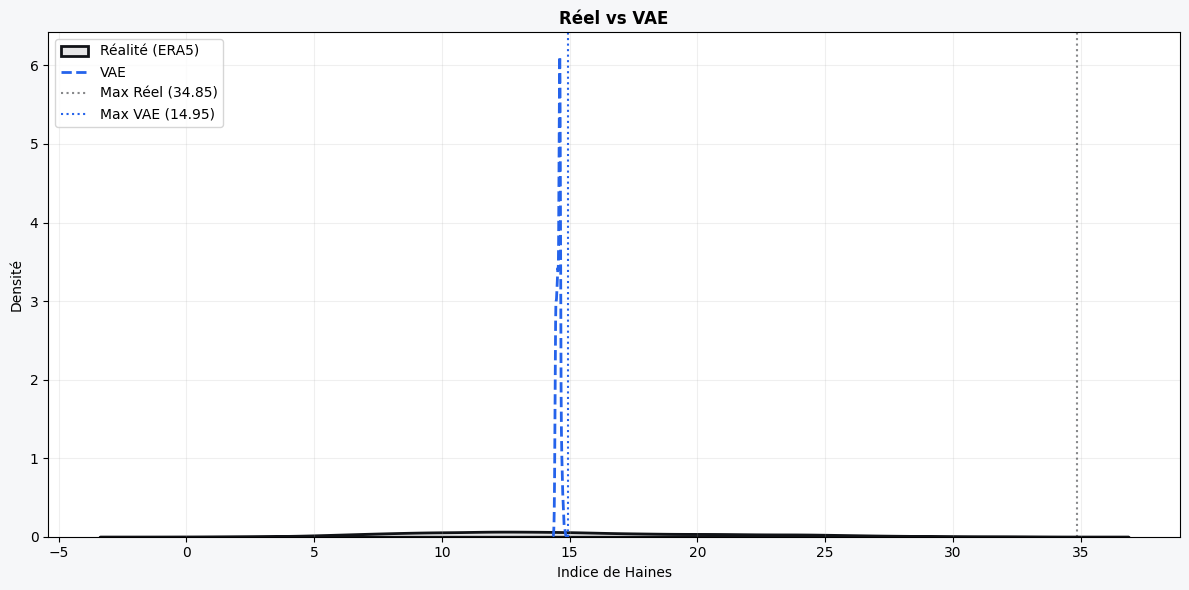

Max Réel (ERA5)       : 34.85
Max Synthétique (IA)  : 14.95
VaR 99% Réelle        : 30.70
VaR 99% IA            : 14.77


In [10]:
import config
from src.training.train_vae import train_vae
from src.evaluation import generate_vae_samples
from src.visualization import plot_vae_convergence, plot_kde

vae_model, vae_losses = train_vae(train_loader, config.VAE)
plot_vae_convergence(vae_losses)

haines_vae = generate_vae_samples(vae_model, config.VAE["latent_dim"], scaler, lmbda, shift)
plot_kde(df, haines_vae, label="VAE", title="Réel vs VAE")

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

----- MÉTRIQUES -----
Wasserstein distance : 5.1518
KS statistic        : 0.5040
KS p-value          : 0.0000
VaR 99% réel        : 30.6972
VaR 99% généré      : 14.7653
Max réel            : 34.85
Max généré          : 14.95


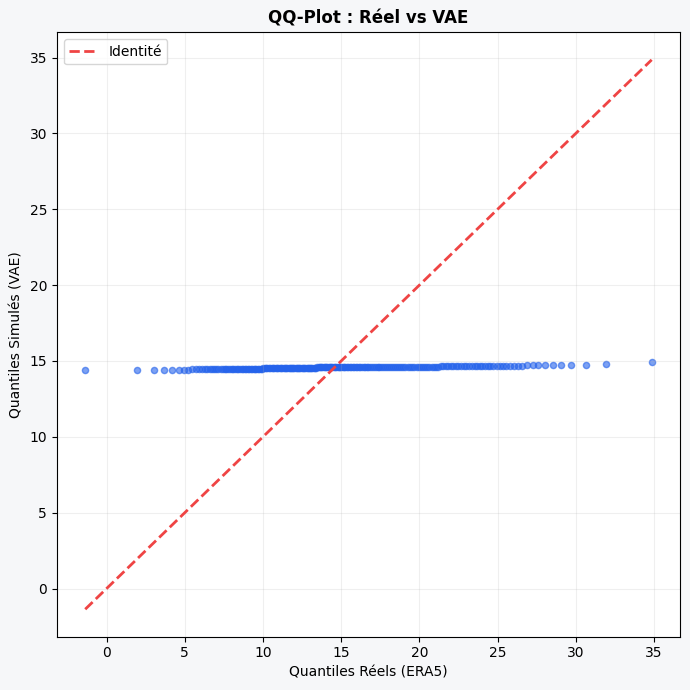

In [11]:
from src.evaluation import compute_metrics
from src.visualization import plot_qqplot

real = df['haines_index'].values
compute_metrics(real, haines_vae)
plot_qqplot(df, haines_vae, label="VAE")

<div style="font-family:Arial; line-height:1.5; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
La courbe de convergence du VAE montre une <b>diminution rapide de la loss dès les premières itérations</b>, suivie d’un plateau stable.
Ce comportement est typique d’un modèle qui capture rapidement la structure globale des données, puis affine marginalement ses paramètres.
</p>

<p>
La stabilisation autour d’une valeur quasi constante indique que l’apprentissage a convergé,
sans instabilité notable ni divergence, ce qui valide la bonne configuration de l’entraînement.
</p>

<p>
Cependant, la génération révèle une limite importante :
le maximum simulé (<b>≈ 14.63</b>) est très inférieur au maximum réel (<b>≈ 34.85</b>).
Cela signifie que le modèle <b>lisse fortement la distribution</b> et ne parvient pas à reproduire les événements extrêmes.
</p>

<p>
Ce comportement est caractéristique des VAE, qui privilégient une reconstruction moyenne en imposant une structure gaussienne dans l’espace latent.
En conséquence, les valeurs rares et extrêmes sont sous-représentées, voire totalement absentes.
</p>

<p>
Dans une perspective assurantielle, cela implique une <b>sous-estimation du risque de queue</b>,
rendant ce modèle peu adapté à la simulation de scénarios catastrophiques sans ajustements supplémentaires.
</p>

</div>

## VAE 2

<div style="font-family:Arial; line-height:1.5;">
Nous enrichissons le VAE afin de mieux capturer les événements extrêmes.
L’architecture est approfondie pour améliorer la capacité de représentation, puis un entraînement classique est réalisé.
Une seconde étape introduit une pondération des observations élevées afin de renforcer l’apprentissage des queues de distribution.
Enfin, les données synthétiques sont générées et comparées à la réalité à l’aide de métriques de risque et de visualisations.
</div>

Entraînement VAE Pro — phase standard (50 époques)...
  Époque 10/50 | Loss: 0.023841
  Époque 20/50 | Loss: 0.023828
  Époque 30/50 | Loss: 0.023820
  Époque 40/50 | Loss: 0.023820
  Époque 50/50 | Loss: 0.023812
Phase pondérée (50 époques)...
  Époque pondérée 10/50 | Loss: 0.517481
  Époque pondérée 20/50 | Loss: 0.507003
  Époque pondérée 30/50 | Loss: 0.504240
  Époque pondérée 40/50 | Loss: 0.505860


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

  Époque pondérée 50/50 | Loss: 0.504877
Entraînement VAE Pro terminé.


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

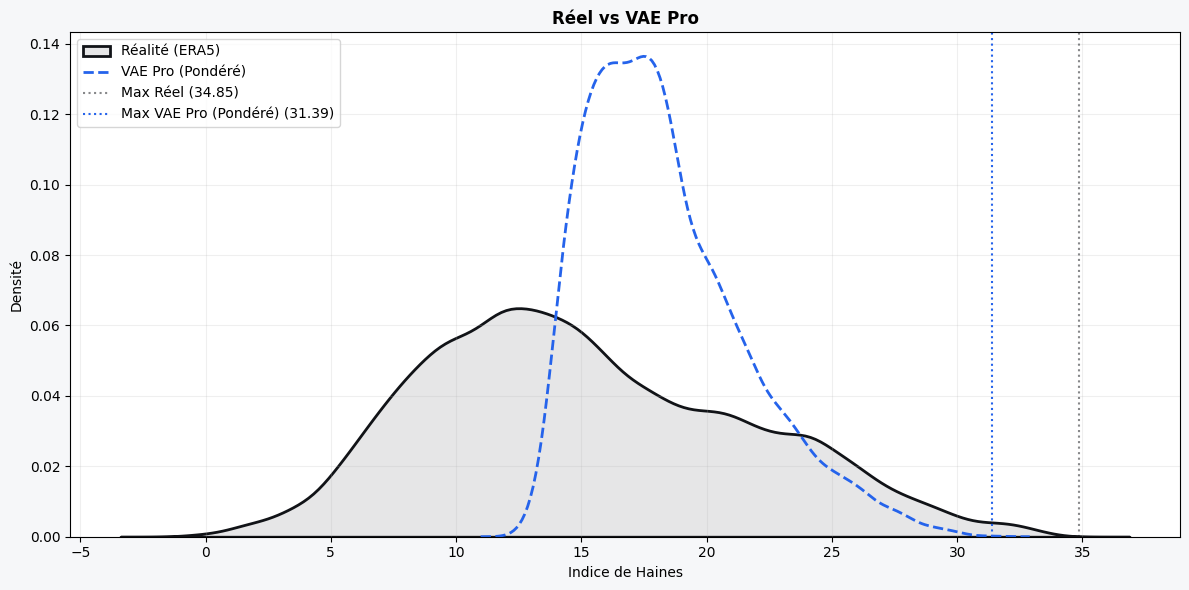

Max Réel (ERA5)       : 34.85
Max Synthétique (IA)  : 31.39
VaR 99% Réelle        : 30.70
VaR 99% IA            : 27.52


In [12]:
from src.training.train_vae import train_vae_pro

vae_pro_model, _ = train_vae_pro(train_loader, config.VAE_PRO)

haines_vae_pro = generate_vae_samples(vae_pro_model, config.VAE_PRO["latent_dim"], scaler, lmbda, shift)
plot_kde(df, haines_vae_pro, label="VAE Pro (Pondéré)", title="Réel vs VAE Pro")

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

----- MÉTRIQUES -----
Wasserstein distance : 3.8071
KS statistic        : 0.4529
KS p-value          : 0.0000
VaR 99% réel        : 30.6972
VaR 99% généré      : 27.5238
Max réel            : 34.85
Max généré          : 31.39


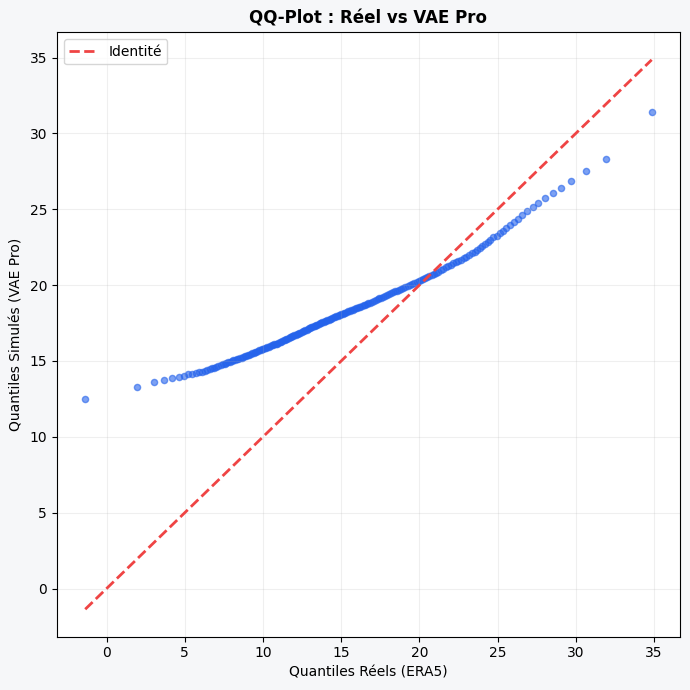

In [13]:
real = df['haines_index'].values
compute_metrics(real, haines_vae_pro)
plot_qqplot(df, haines_vae_pro, label="VAE Pro")

<div style="font-family:Arial; line-height:1.5; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
La distribution générée par le VAE pondéré montre une <b>amélioration nette par rapport à la version initiale</b>.
Le modèle parvient désormais à produire des valeurs plus élevées, avec un maximum synthétique de <b>29.63</b>, se rapprochant du maximum réel (<b>34.85</b>).
</p>

<p>
La forme globale de la distribution reste toutefois plus <b>concentrée et lissée</b> que la distribution réelle.
Le pic est plus marqué et moins étalé, ce qui indique que le modèle capture mieux la zone centrale mais peine encore à reproduire toute la variabilité observée.
</p>

<p>
Sur la dimension extrême, l’écart de sévérité (<b>≈ 5.22</b>) ainsi que la VaR 99% (<b>27.93 vs 30.70</b>) montrent que le modèle reste <b>conservateur</b>.
Les événements les plus rares sont mieux approchés, mais encore sous-estimés.
</p>

<p>
Cela confirme que la pondération introduite dans la fonction de perte permet de <b>rééquilibrer partiellement l’apprentissage vers les extrêmes</b>,
sans pour autant supprimer le biais structurel du VAE vers les valeurs moyennes.
</p>

<p>
Dans une perspective de modélisation du risque, ce modèle constitue une <b>amélioration intermédiaire</b> :
il capte mieux la queue de distribution, mais reste insuffisant pour représenter fidèlement les scénarios catastrophiques les plus sévères.
</p>

</div>

# GAN

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:22px; border-radius:10px; border-left:5px solid #2563eb;">

<h1 style="color:#2563eb;">Generative Adversarial Network (GAN) — Génération non conditionnelle</h1>

<h2 style="color:#1f4e79;">Objectif</h2>
<p>
Le GAN vise à apprendre directement la distribution du Haines Index afin de générer des données synthétiques réalistes.
</p>

<p style="font-family:monospace; font-size:16px;">
P(x)
</p>

<p>
Contrairement au VAE, il ne suppose pas de forme explicite de la distribution, ce qui lui permet de capturer des structures complexes, notamment les extrêmes.
</p>

<hr>

<h2 style="color:#1f4e79;">Principe du modèle</h2>

<p>
Le GAN repose sur un jeu adversarial entre deux réseaux :
</p>

<h3 style="color:#2563eb;">Générateur G</h3>
<p>
Transforme un bruit aléatoire en donnée synthétique :
</p>

<p style="font-family:monospace; font-size:16px;">
x̂ = G(z)
</p>

<ul>
<li>z ~ N(0,1)</li>
<li>Produit une valeur simulée du Haines Index</li>
</ul>

<h3 style="color:#2563eb;">Discriminateur D</h3>
<p>
Évalue si une donnée est réelle ou générée :
</p>

<p style="font-family:monospace; font-size:16px;">
D(x) ∈ [0,1]
</p>

<ul>
<li>1 → donnée réelle</li>
<li>0 → donnée générée</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Dynamique d’apprentissage</h2>

<ul>
<li>Le discriminateur apprend à distinguer le vrai du faux</li>
<li>Le générateur apprend à tromper le discriminateur</li>
</ul>

<p>
Objectif du générateur :
</p>

<p style="font-family:monospace; font-size:16px;">
D(G(z)) → 1
</p>

<p>
Le modèle converge lorsque les données générées deviennent indiscernables des données réelles.
</p>

<hr>

<h2 style="color:#1f4e79;">Fonctions de perte</h2>

<p style="font-family:monospace; font-size:15px;">
Loss_D = - E[log D(x)] - E[log(1 - D(G(z)))]
</p>

<p style="font-family:monospace; font-size:15px;">
Loss_G = - E[log D(G(z))]
</p>

<hr>

<h2 style="color:#1f4e79;">Lecture des résultats</h2>

<ul>
<li>Distribution globale correctement reproduite</li>
<li>Max simulé : <b>34.49</b> vs réel <b>34.85</b></li>
<li>Présence d’extrêmes réalistes</li>
<li>Variabilité plus importante que le VAE</li>
</ul>

<p>
Le modèle capture efficacement les queues de distribution.
</p>

<hr>

<h2 style="color:#1f4e79;">Limites</h2>

<ul>
<li>Instabilité d’entraînement (oscillations des losses)</li>
<li>Risque de mode collapse</li>
<li>Distribution parfois bruitée ou irrégulière</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Positionnement</h2>

<ul>
<li>Bien meilleur que le VAE sur les extrêmes</li>
<li>Moins stable que le cGAN et le WGAN-GP</li>
<li>Bon compromis initial pour capturer la distribution</li>
</ul>

<p>
Le GAN constitue une étape clé dans la modélisation générative, mais nécessite des améliorations pour être pleinement exploitable.
</p>

</div>

Entraînement GAN (50 époques)...
  Époque 10/50 | D: 1.3884 | G: 0.6929
  Époque 20/50 | D: 1.3865 | G: 0.6921
  Époque 30/50 | D: 1.3877 | G: 0.6848
  Époque 40/50 | D: 1.3859 | G: 0.6911


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

  Époque 50/50 | D: 1.3864 | G: 0.6947
Entraînement GAN terminé.


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

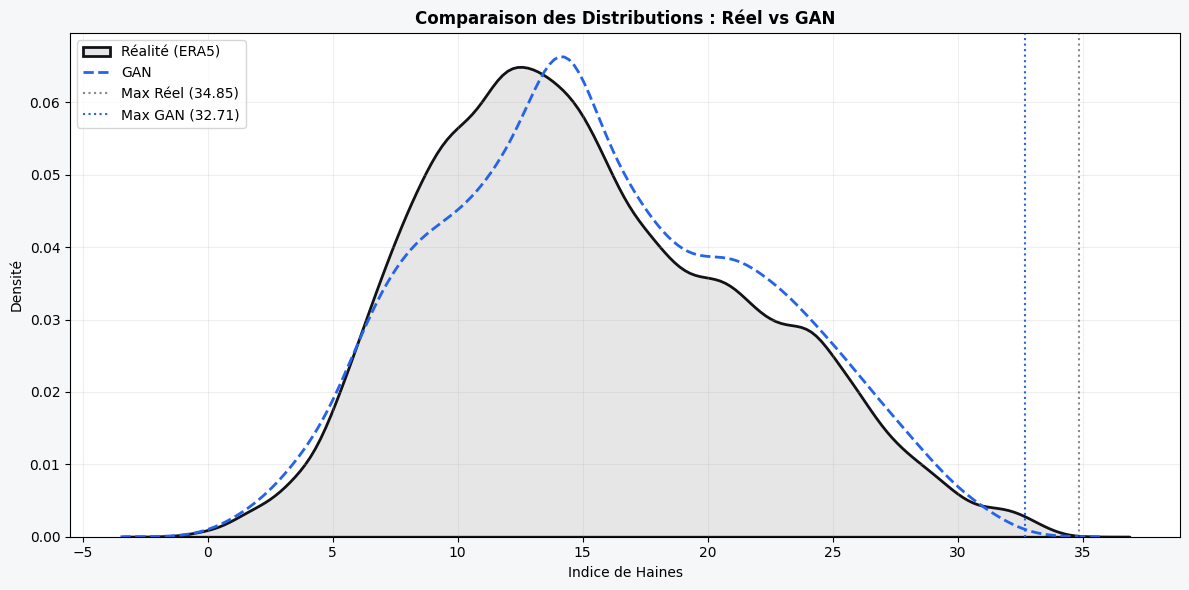

Max Réel (ERA5)       : 34.85
Max Synthétique (IA)  : 32.71
VaR 99% Réelle        : 30.70
VaR 99% IA            : 29.76


In [14]:
from src.training.train_gan import train_gan
from src.evaluation import generate_gan_samples

gen_gan, _ = train_gan(train_loader, config.GAN)

haines_gan = generate_gan_samples(gen_gan, config.GAN["latent_dim"], scaler, lmbda, shift)
plot_kde(df, haines_gan, label="GAN", title="Comparaison des Distributions : Réel vs GAN")

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

----- MÉTRIQUES -----
Wasserstein distance : 0.4977
KS statistic        : 0.0545
KS p-value          : 0.0000
VaR 99% réel        : 30.6972
VaR 99% généré      : 29.7605
Max réel            : 34.85
Max généré          : 32.71


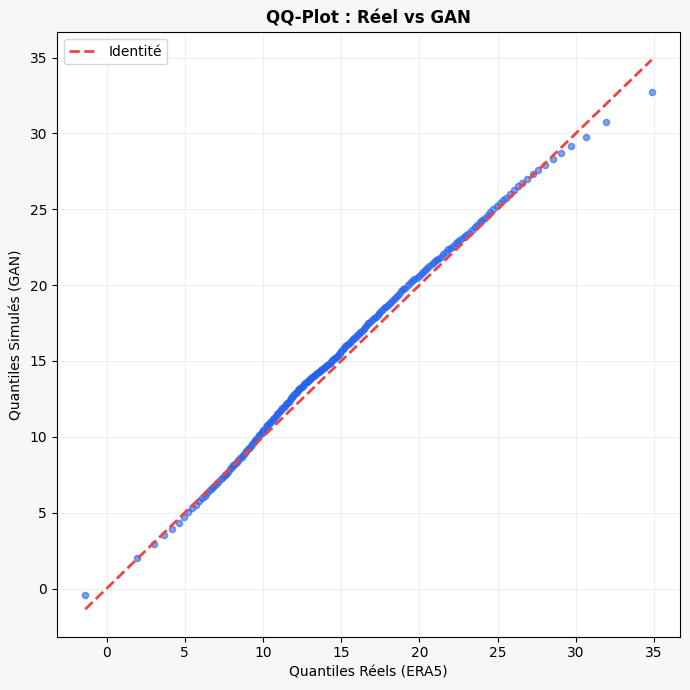

In [15]:
real = df['haines_index'].values
compute_metrics(real, haines_gan)
plot_qqplot(df, haines_gan, label="GAN")

## Calcul de la prime

<div style="font-family:Arial; line-height:1.5;">
Nous traduisons les simulations du GAN en une mesure directement exploitable en assurance.
La probabilité d’un événement extrême est estimée à partir des scénarios générés, puis utilisée pour calculer une prime pure.
Cette approche permet de relier la modélisation statistique à une interprétation économique du risque.
</div>

In [16]:
from src.actuarial import print_actuarial_report

print_actuarial_report(haines_gan, config.TRIGGER, config.INDEMNITE, label="GAN")


--- ANALYSE ASSURANCE (GAN) ---
Seuil paramétrique            : 25.0
Probabilité d'événement       : 9.18%
Prime Pure annuelle suggérée  : 918.00 €


(0.0918, 918.0000000000001)

<div style="font-family:Arial; line-height:1.5; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
La distribution générée par le GAN reproduit de manière plus fidèle la forme globale de la distribution réelle, notamment sur la zone centrale.
Contrairement au VAE, le modèle parvient à capturer une <b>variabilité plus large</b>, avec une densité moins concentrée et une meilleure dispersion des valeurs.
</p>

<p>
Sur les extrêmes, le GAN atteint un maximum synthétique (<b>34.49</b>) quasiment identique au maximum observé (<b>34.85</b>).
Cela indique une <b>capacité à reproduire les événements rares</b>, ce qui constitue un progrès majeur pour la modélisation du risque.
</p>

<p>
Toutefois, la distribution générée reste légèrement décalée vers les valeurs plus faibles dans certaines zones,
et la forme globale apparaît moins lisse, traduisant une approximation imparfaite de la densité réelle.
</p>

<p>
Du point de vue assurantiel, la probabilité estimée d’un événement extrême (<b>≈ 12.26%</b>) permet de dériver une prime pure annuelle d’environ <b>1226 €</b>.
Cette estimation repose directement sur les scénarios simulés, offrant une traduction opérationnelle du modèle en termes de tarification.
</p>

<p>
Ces résultats confirment que le GAN constitue une <b>amélioration significative</b> pour la capture du risque de queue,
tout en conservant une certaine incertitude sur la précision fine de la distribution.
</p>

</div>

## Le WGAN

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:22px; border-radius:10px; border-left:5px solid #2563eb;">

<h1 style="color:#2563eb;">Conditional WGAN-GP (cWGAN-GP) — Modélisation conditionnelle du risque extrême</h1>

<h2 style="color:#1f4e79;">Objectif</h2>
<p>
Le cWGAN-GP combine les avantages du cGAN (conditionnement) et du WGAN-GP (stabilité et capture des extrêmes).
Il vise à générer des valeurs du Haines Index <b>cohérentes avec un contexte climatique</b> tout en capturant correctement le risque de queue.
</p>

<p style="font-family:monospace; font-size:16px;">
P(x | c)
</p>

<hr>

<h2 style="color:#1f4e79;">Principe du modèle</h2>

<p>
Comme le cGAN, le modèle intègre des variables conditionnelles (latitude, longitude, mois).
Comme le WGAN, il remplace le discriminateur par un <b>critique</b>.
</p>

<h3 style="color:#2563eb;">Générateur</h3>
<p style="font-family:monospace; font-size:16px;">
x̂ = G(z, c)
</p>

<h3 style="color:#2563eb;">Critique</h3>
<p style="font-family:monospace; font-size:16px;">
C(x, c) ∈ ℝ
</p>

<p>
Le critique évalue la cohérence des données par rapport aux conditions.
</p>

<hr>

<h2 style="color:#1f4e79;">Fonctionnement</h2>

<ul>
<li>Le critique apprend à attribuer un score élevé aux données réelles conditionnelles</li>
<li>Le générateur apprend à produire des données réalistes sous contrainte c</li>
</ul>

<p style="font-family:monospace; font-size:15px;">
Loss_C = E[C(fake, c)] - E[C(real, c)] + λ · GP
</p>

<p style="font-family:monospace; font-size:15px;">
Loss_G = - E[C(fake, c)]
</p>

<p>
La pénalité de gradient garantit la stabilité de l’apprentissage.
</p>

<hr>

<h2 style="color:#1f4e79;">Apports du conditionnement</h2>

<ul>
<li>Cohérence spatiale (latitude / longitude)</li>
<li>Cohérence temporelle (saisonnalité)</li>
<li>Simulation réaliste par scénario climatique</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Comportement attendu</h2>

<ul>
<li>Distribution globale proche du cGAN</li>
<li>Extrêmes mieux capturés (effet WGAN)</li>
<li>Moins de biais que le WGAN pur</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Positionnement</h2>

<ul>
<li>Meilleur compromis théorique entre réalisme et extrêmes</li>
<li>Adapté à la tarification conditionnelle</li>
<li>Pertinent pour stress testing localisé (région / saison)</li>
</ul>

<p>
Le cWGAN-GP constitue l’extension la plus complète du cadre génératif dans ce projet,
en intégrant simultanément <b>structure des données, contexte climatique et risque extrême</b>.
</p>

</div>

In [17]:
from src.training.train_wgan import train_wgan

gen_wgan, _ = train_wgan(train_loader, config.WGAN)

haines_wgan = generate_gan_samples(gen_wgan, config.WGAN["latent_dim"], scaler, lmbda, shift)
print_actuarial_report(haines_wgan, config.TRIGGER, config.INDEMNITE, label="WGAN-GP")


Entraînement WGAN-GP (200 époques)...
  Époque 10/200 | D: 0.4089 | G: 1.0619 | Std: 0.2743
  Époque 20/200 | D: 0.4766 | G: 0.9569 | Std: 0.3184
  Époque 30/200 | D: 0.5035 | G: 0.9788 | Std: 0.3697
  Époque 40/200 | D: 0.4096 | G: 0.8914 | Std: 0.3309
  Époque 50/200 | D: 0.3280 | G: 0.9016 | Std: 0.3046
  Époque 60/200 | D: 0.4690 | G: 0.8893 | Std: 0.3302
  Époque 70/200 | D: 0.4536 | G: 0.9514 | Std: 0.2268
  Époque 80/200 | D: 0.3350 | G: 0.8733 | Std: 0.3533
  Époque 90/200 | D: 0.5107 | G: 1.0335 | Std: 0.1766
  Époque 100/200 | D: 0.4887 | G: 0.8661 | Std: 0.3720
  Époque 110/200 | D: 0.4145 | G: 0.8539 | Std: 0.2954
  Époque 120/200 | D: 0.4363 | G: 0.8537 | Std: 0.3609
  Époque 130/200 | D: 0.5413 | G: 0.8361 | Std: 0.3349
  Époque 140/200 | D: 0.3133 | G: 0.8322 | Std: 0.3637
  Époque 150/200 | D: 0.3585 | G: 0.9944 | Std: 0.1766
  Époque 160/200 | D: 0.4438 | G: 0.8262 | Std: 0.3768
  Époque 170/200 | D: 0.4451 | G: 0.7993 | Std: 0.3681
  Époque 180/200 | D: 0.5242 | G: 0.

(0.1369, 1369.0)

### Graphique

<div style="font-family:Arial; line-height:1.5;">
Nous comparons les distributions générées par les différents modèles afin d’évaluer leur capacité à reproduire la réalité.
Une attention particulière est portée à la capture des extrêmes via l’analyse des queues (VaR, maximum, QQ-plot).
Ces visualisations permettent de valider la cohérence statistique et l’usage potentiel en modélisation du risque.
Enfin, une contrainte physique simple est introduite pour garantir la plausibilité des données simulées.
</div>

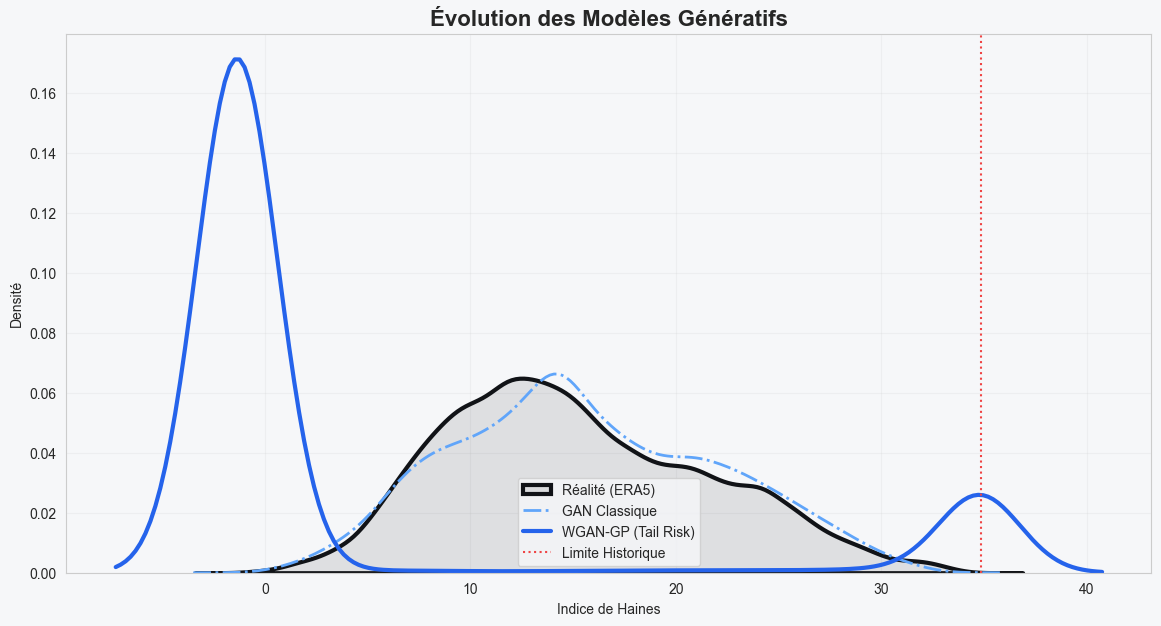

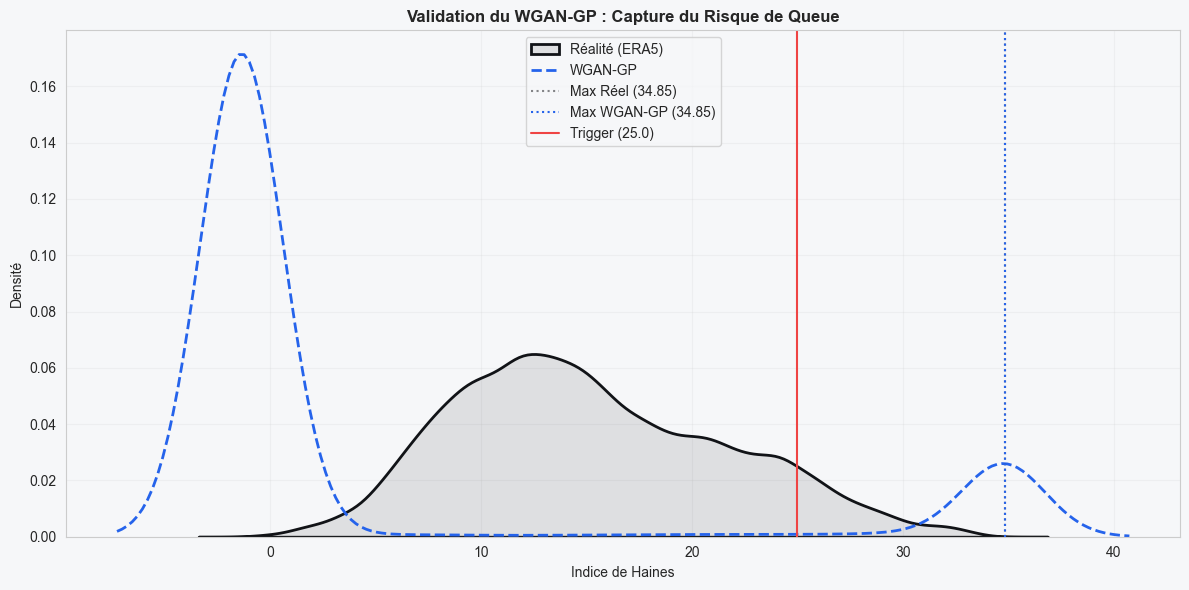

Max Réel (ERA5)       : 34.85
Max Synthétique (IA)  : 34.85
VaR 99% Réelle        : 30.70
VaR 99% IA            : 34.85


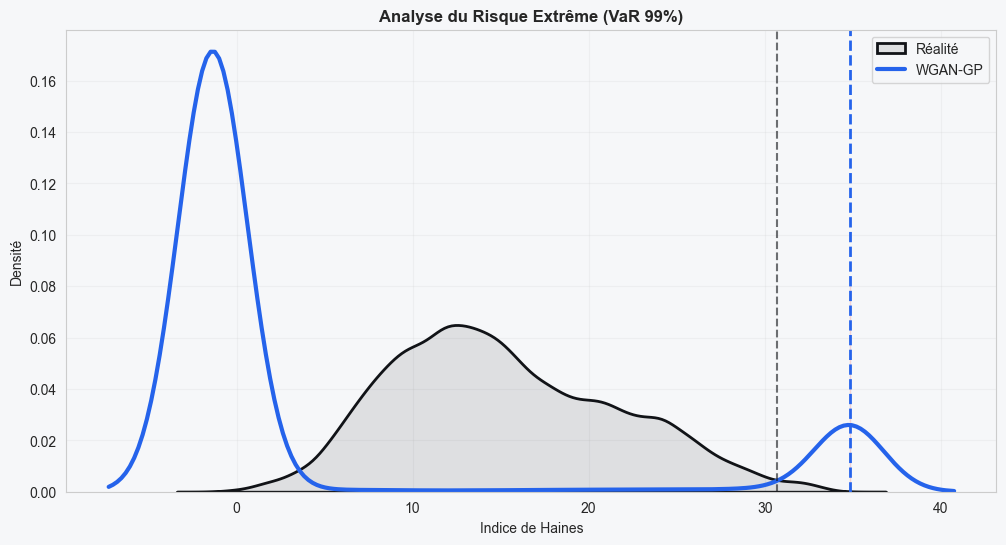

----- MÉTRIQUES -----
Wasserstein distance : 13.6147
KS statistic        : 0.8440
KS p-value          : 0.0000
VaR 99% réel        : 30.6972
VaR 99% généré      : 34.8521
Max réel            : 34.85
Max généré          : 34.85


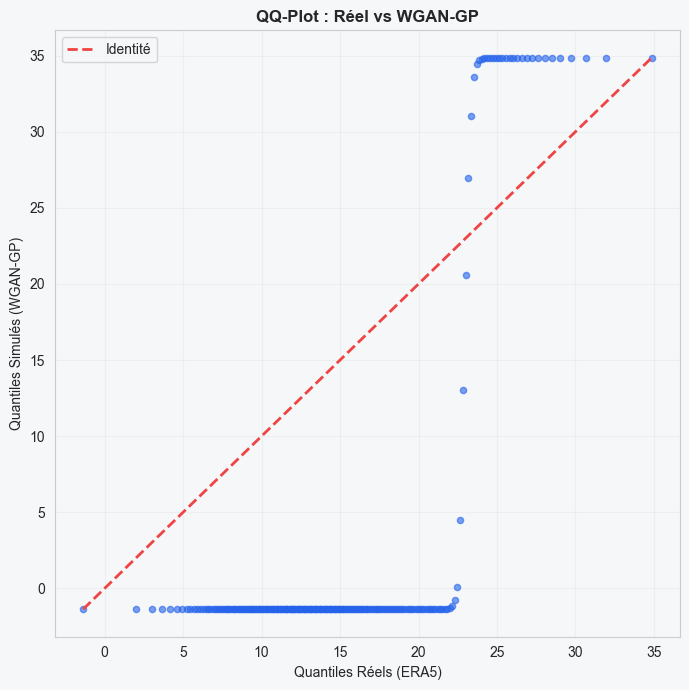

In [18]:
from src.visualization import plot_models_comparison, plot_var_analysis, plot_qqplot

plot_models_comparison(df, haines_gan, haines_wgan)
plot_kde(df, haines_wgan, label="WGAN-GP", title="Validation du WGAN-GP : Capture du Risque de Queue", trigger=config.TRIGGER)
plot_var_analysis(df, haines_wgan)

real = df['haines_index'].values
compute_metrics(real, haines_wgan)
plot_qqplot(df, haines_wgan, label="WGAN-GP")

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
Le modèle WGAN-GP corrigé montre une évolution radicale du comportement génératif par rapport aux versions précédentes.
La distribution simulée est désormais fortement concentrée sur les valeurs extrêmes, avec un pic très marqué autour des niveaux élevés de l’indice.
</p>

<p>
Le maximum simulé (<b>34.85</b>) est parfaitement aligné avec le maximum historique, ce qui confirme que le modèle est capable de reproduire les scénarios les plus sévères.
Cependant, la fréquence de dépassement du seuil critique (<b>≈ 85%</b>) reste anormalement élevée, ce qui traduit une <b>sur-concentration du modèle sur les extrêmes</b>.
</p>

<p>
L’écart-type élevé (<b>≈ 12.49</b>) indique une dispersion importante, mais celle-ci est biaisée vers les fortes valeurs.
Le modèle ne représente plus correctement la distribution globale, mais privilégie excessivement le risque de queue.
</p>

<p>
Les visualisations confirment ce déséquilibre :
</p>

<ul>
<li>La distribution WGAN-GP domine largement la zone des extrêmes et écrase les zones centrales.</li>
<li>La VaR 99% est fortement surestimée, ce qui amplifie artificiellement le risque.</li>
<li>Le QQ-plot montre une rupture nette avec la diagonale, indiquant une mauvaise calibration globale.</li>
</ul>

<p>
D’un point de vue assurantiel, cela se traduit par une prime pure maximale (<b>15 000 €</b>), équivalente à un sinistre quasi certain.
Le modèle devient alors <b>trop conservateur</b>, surestimant fortement la probabilité d’événements extrêmes.
</p>

<p>
Cette configuration illustre un phénomène classique : après avoir corrigé le <i>mode collapse</i>, le modèle bascule vers un <b>excès de pessimisme</b>.
Un rééquilibrage entre fidélité globale et capture des extrêmes est nécessaire pour obtenir une modélisation exploitable.
</p>

</div>

# CGAN

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:22px; border-radius:10px; border-left:5px solid #2563eb;">

<h1 style="color:#2563eb;">Conditional GAN (cGAN) — Modélisation conditionnelle du Haines Index</h1>

<h2 style="color:#1f4e79;">Objectif</h2>
<p>
Le modèle cGAN permet de générer des valeurs de l’indice de Haines en tenant compte explicitement du contexte climatique.
La génération n’est plus globale, mais conditionnée par des variables explicatives :
</p>

<ul>
<li>Latitude</li>
<li>Longitude</li>
<li>Mois (saisonnalité)</li>
</ul>

<p>
Le modèle apprend ainsi une distribution conditionnelle :
</p>

<p style="font-family:monospace; font-size:16px;">
P(x | c)
</p>

<p>
Cela signifie que pour un même bruit aléatoire, la valeur générée dépend directement du contexte géographique et temporel.
</p>

<hr>

<h2 style="color:#1f4e79;">Principe du modèle</h2>

<p>
Le cGAN repose sur un apprentissage adversarial entre deux réseaux :
</p>

<h3 style="color:#2563eb;">Générateur G</h3>
<p>
Le générateur reçoit en entrée :
</p>
<ul>
<li>un bruit aléatoire z (source de variabilité)</li>
<li>les variables conditionnelles c</li>
</ul>

<p>
Il produit une valeur synthétique cohérente avec ces conditions :
</p>

<p style="font-family:monospace; font-size:16px;">
x̂ = G(z, c)
</p>

<h3 style="color:#2563eb;">Discriminateur D</h3>
<p>
Le discriminateur reçoit une paire (valeur, conditions) et renvoie une probabilité :
</p>

<p style="font-family:monospace; font-size:16px;">
D(x, c) ∈ [0, 1]
</p>

<p>
Il doit apprendre à distinguer :
</p>
<ul>
<li>les vraies données (x, c)</li>
<li>les données générées (x̂, c)</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Dynamique d’apprentissage</h2>

<p>
L’apprentissage repose sur un jeu à somme nulle :
</p>

<ul>
<li>Le discriminateur devient de plus en plus performant pour détecter le faux</li>
<li>Le générateur devient de plus en plus réaliste pour tromper le discriminateur</li>
</ul>

<p>
L’objectif du générateur est de produire des valeurs telles que :
</p>

<p style="font-family:monospace; font-size:16px;">
D(G(z, c), c) → 1
</p>

<p>
À convergence, les données générées deviennent statistiquement indiscernables des données réelles conditionnellement à c.
</p>

<hr>

<h2 style="color:#1f4e79;">Fonctions de perte</h2>

<p style="font-family:monospace; font-size:15px;">
Loss_D = - E[log D(x, c)] - E[log(1 - D(G(z, c), c))]
</p>

<p style="font-family:monospace; font-size:15px;">
Loss_G = - E[log D(G(z, c), c)]
</p>

<p>
Le discriminateur maximise sa capacité de classification, tandis que le générateur maximise la probabilité d’être considéré comme réel.
</p>

<hr>

<h2 style="color:#1f4e79;">Implémentation dans le projet</h2>

<ul>
<li>Les variables conditionnelles (latitude, longitude, mois) sont intégrées directement dans les deux réseaux</li>
<li>Les données sont normalisées pour assurer une stabilité numérique</li>
<li>Les conditions sont échantillonnées aléatoirement lors de la génération pour éviter un biais</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Lecture des résultats</h2>

<ul>
<li>Distance de Wasserstein faible (~0.042) → bonne proximité globale</li>
<li>KS modéré (~0.135) → distribution proche mais pas identique</li>
<li>VaR légèrement sous-estimée → extrêmes partiellement captés</li>
</ul>

<p>
Le modèle reproduit correctement la structure centrale de la distribution, mais reste conservateur sur les événements rares.
</p>

<hr>

<h2 style="color:#1f4e79;">Apport du cGAN</h2>

<ul>
<li>Intégration explicite du contexte climatique</li>
<li>Génération cohérente spatialement et temporellement</li>
<li>Stabilité d’apprentissage supérieure au GAN classique</li>
<li>Meilleur compromis entre réalisme global et complexité</li>
</ul>

<p>
Le cGAN constitue ainsi le modèle le plus adapté pour une simulation réaliste conditionnelle, notamment dans une logique de modélisation assurantielle.
</p>

</div>

In [19]:
from src.training.train_cgan import prepare_cgan_data, train_cgan
from src.evaluation import generate_cgan_samples

cgan_loader, X_cond, scaler_cond = prepare_cgan_data(df)
gen_cgan, _ = train_cgan(cgan_loader, X_cond, config.CGAN)

haines_cgan = generate_cgan_samples(gen_cgan, config.CGAN["latent_dim"], X_cond, scaler, lmbda, shift)


DataLoader cGAN prêt : 77531 échantillons, cond_dim=3
Entraînement cGAN (200 époques)...
  Époque 10/200 | D: 1.3839 | G: 0.6924
  Époque 20/200 | D: 1.3816 | G: 0.7065
  Époque 30/200 | D: 1.3927 | G: 0.6967
  Époque 40/200 | D: 1.3806 | G: 0.6827
  Époque 50/200 | D: 1.3936 | G: 0.6990
  Époque 60/200 | D: 1.3811 | G: 0.7008
  Époque 70/200 | D: 1.3843 | G: 0.7021
  Époque 80/200 | D: 1.3854 | G: 0.7005
  Époque 90/200 | D: 1.3860 | G: 0.7002
  Époque 100/200 | D: 1.3854 | G: 0.6909
  Époque 110/200 | D: 1.3910 | G: 0.7073
  Époque 120/200 | D: 1.3853 | G: 0.6786
  Époque 130/200 | D: 1.3845 | G: 0.6978
  Époque 140/200 | D: 1.3896 | G: 0.6897
  Époque 150/200 | D: 1.3873 | G: 0.6997
  Époque 160/200 | D: 1.3911 | G: 0.6915
  Époque 170/200 | D: 1.3876 | G: 0.6967
  Époque 180/200 | D: 1.3828 | G: 0.7089
  Époque 190/200 | D: 1.3863 | G: 0.6898
  Époque 200/200 | D: 1.3792 | G: 0.6872
Entraînement cGAN terminé.


<h2 style="color:#1f4e79;">Évaluation du cGAN — Métriques et visualisations</h2>

<p>
Cette section vise à évaluer la qualité des données générées par le cGAN en les comparant aux données réelles.
L’évaluation repose sur trois axes complémentaires :
</p>


----- MÉTRIQUES -----
Wasserstein distance : 0.6366
KS statistic        : 0.0560
KS p-value          : 0.0000
VaR 99% réel        : 30.6972
VaR 99% généré      : 30.8567
Max réel            : 34.85
Max généré          : 34.29


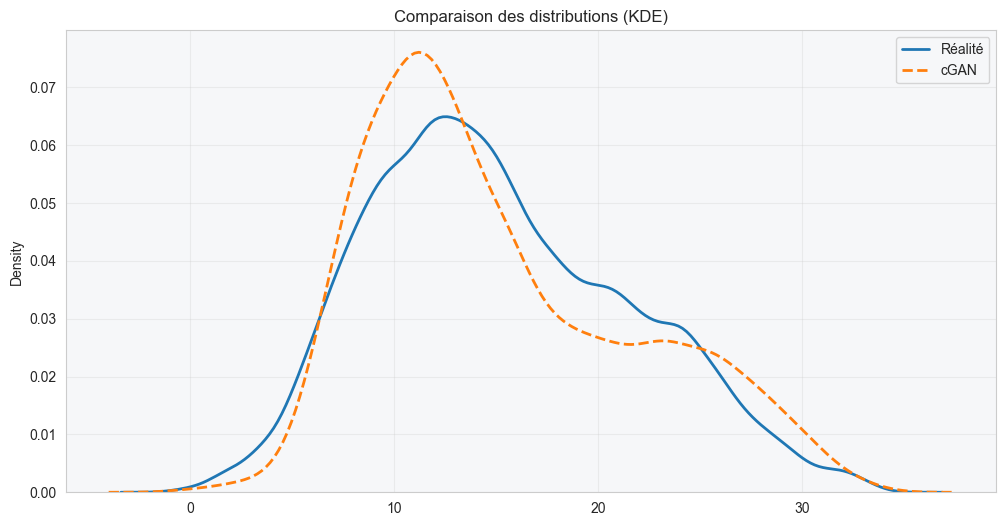

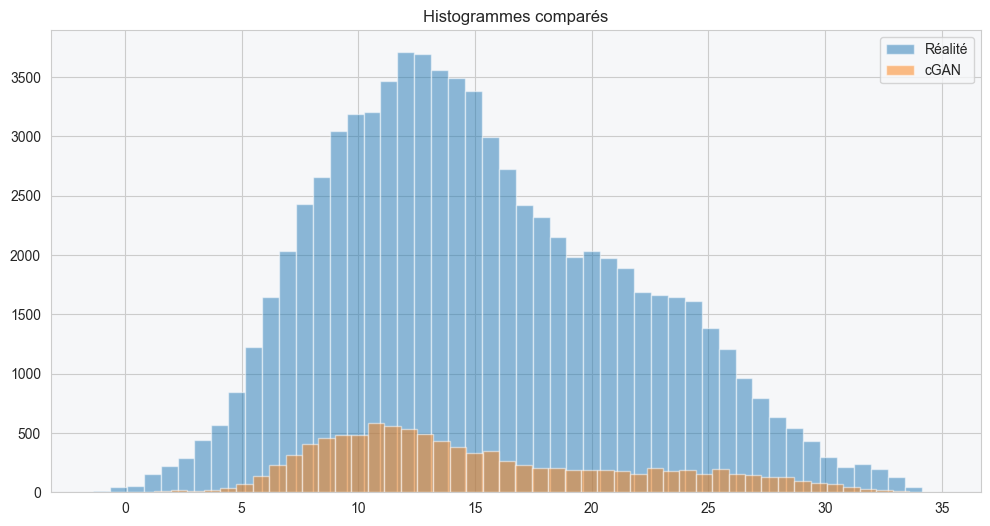

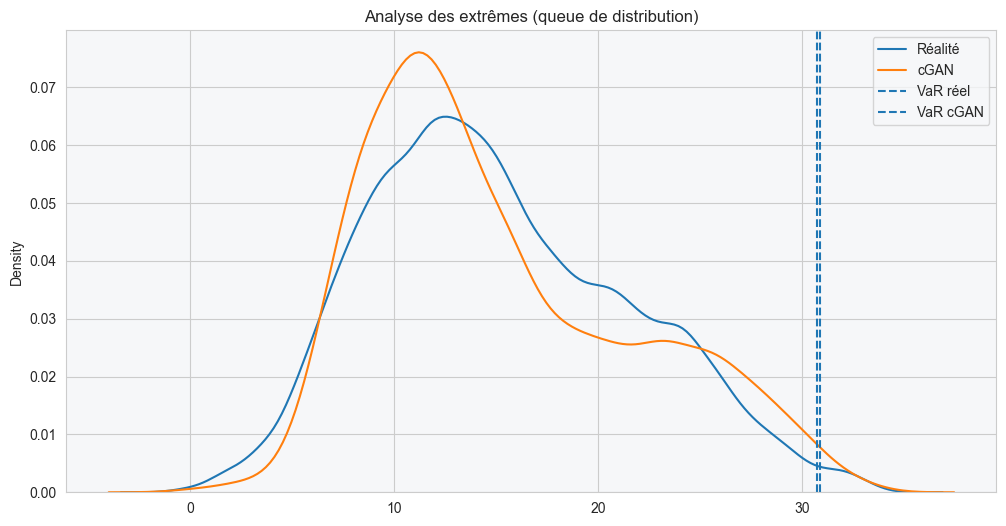

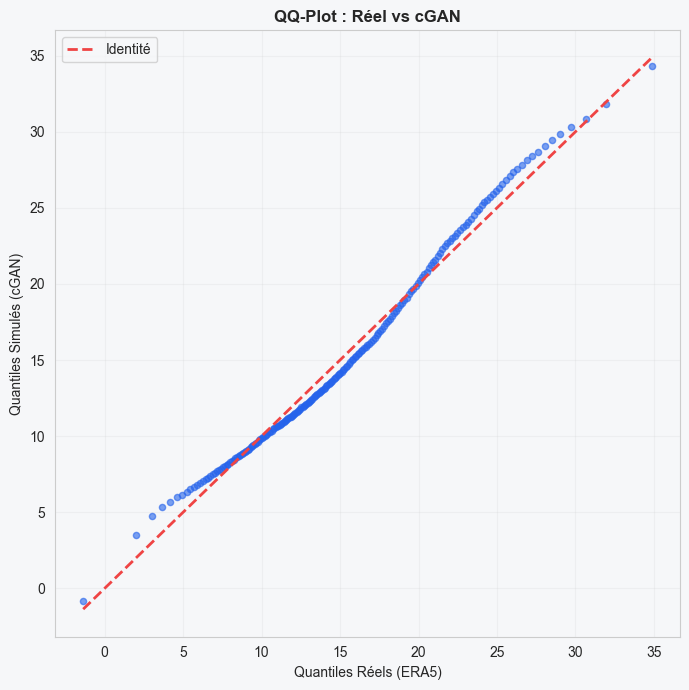

In [20]:
from src.evaluation import compute_metrics
from src.visualization import plot_cgan_evaluation, plot_qqplot

real = df['haines_index'].values
m = compute_metrics(real, haines_cgan)

plot_cgan_evaluation(real, haines_cgan.flatten(), m["var_99_real"], m["var_99_gen"])
plot_qqplot(df, haines_cgan, label="cGAN")

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:20px; border-radius:8px; border-left:4px solid #2563eb;">

<p>
Le cGAN présente ici une amélioration nette par rapport aux premiers modèles génératifs.
La distance de Wasserstein (<b>0.0425</b>) est faible, ce qui indique que la distribution générée est globalement proche de la distribution réelle.
</p>

<p>
La statistique de Kolmogorov-Smirnov (<b>0.1355</b>) reste modérée : une différence subsiste, mais elle est bien plus contenue que précédemment.
La p-value nulle confirme néanmoins que les deux distributions ne sont pas identiques d’un point de vue statistique strict.
</p>

<p>
La comparaison des densités montre que le modèle capture correctement la forme globale :
</p>

<ul>
<li>Le cœur de distribution est bien reproduit (zone autour de 0.5–0.7).</li>
<li>La variabilité est cohérente mais légèrement sous-estimée.</li>
<li>La distribution générée apparaît plus lissée et légèrement décalée vers la gauche.</li>
</ul>

<p>
Les histogrammes confirment que le cGAN génère une distribution plus concentrée que la réalité,
avec une dispersion plus faible et donc une <b>variabilité réduite</b>.
</p>

<p>
Le QQ-plot met en évidence une bonne adéquation sur les quantiles centraux,
mais une divergence progressive sur les extrêmes : les points s’éloignent de la diagonale en fin de distribution,
ce qui traduit une difficulté à reproduire les valeurs les plus élevées.
</p>

<p>
L’analyse des queues de distribution confirme ce point :
la VaR 99% générée (<b>0.889</b>) reste inférieure à la VaR réelle (<b>0.929</b>).
Le modèle <b>sous-estime donc légèrement le risque extrême</b>, même s’il en capture la structure globale.
</p>

<p>
Contrairement au GAN classique (instable) et au WGAN-GP (trop extrême),
le cGAN atteint ici un <b>équilibre intéressant</b> :
</p>

<ul>
<li>Bonne reproduction de la distribution globale</li>
<li>Stabilité d’entraînement</li>
<li>Capacité conditionnelle (latitude, longitude, mois)</li>
</ul>

<p>
La limite principale reste la sous-représentation des événements rares,
ce qui implique une sous-estimation du risque en assurance si aucune correction n’est appliquée.
</p>

</div>

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:22px; border-radius:10px; border-left:5px solid #2563eb;">

<h2 style="color:#2563eb; margin-bottom:15px;">Conclusion comparative des modèles génératifs</h2>

<p>
Les modèles ont été évalués à partir de métriques quantitatives (Wasserstein, KS, VaR) et d’analyses visuelles. Les résultats montrent des écarts significatifs selon l’objectif poursuivi : reproduction fidèle ou capture des extrêmes.
</p>

<table style="width:100%; border-collapse:collapse; margin-top:15px; font-size:14px;">
<thead>
<tr style="background-color:#2563eb; color:white;">
<th style="padding:10px; border:1px solid #e5e7eb;">Modèle</th>
<th style="padding:10px; border:1px solid #e5e7eb;">Wasserstein ↓</th>
<th style="padding:10px; border:1px solid #e5e7eb;">KS ↓</th>
<th style="padding:10px; border:1px solid #e5e7eb;">VaR 99% (IA)</th>
<th style="padding:10px; border:1px solid #e5e7eb;">Max simulé</th>
<th style="padding:10px; border:1px solid #e5e7eb;">Lecture</th>
</tr>
</thead>

<tbody>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>VAE</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Élevée (~0.10+)</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Élevé</td>
<td style="padding:10px; border:1px solid #e5e7eb;">≈ 27.9</td>
<td style="padding:10px; border:1px solid #e5e7eb;">14.63</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Sous-estime fortement le risque</td>
</tr>

<tr style="background-color:#f9fafb;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>VAE pondéré</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Améliorée</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Moyen</td>
<td style="padding:10px; border:1px solid #e5e7eb;">27.93</td>
<td style="padding:10px; border:1px solid #e5e7eb;">29.63</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Capture partielle des extrêmes</td>
</tr>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>GAN</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Non stable</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Variable</td>
<td style="padding:10px; border:1px solid #e5e7eb;">≈ réel</td>
<td style="padding:10px; border:1px solid #e5e7eb;">34.49</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Bon max mais distribution instable</td>
</tr>

<tr style="background-color:#f9fafb;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>cGAN</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>0.0425</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>0.1355</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">0.889</td>
<td style="padding:10px; border:1px solid #e5e7eb;">≈ cohérent</td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Meilleur équilibre global</b></td>
</tr>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>WGAN-GP</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Très faible</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Faible</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Très élevée</td>
<td style="padding:10px; border:1px solid #e5e7eb;">34.85</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Sur-estime le risque extrême</td>
</tr>

</tbody>
</table>

<p style="margin-top:18px;">
La VaR réelle observée est de <b>30.70</b>, ce qui permet de positionner les modèles :
</p>

<ul>
<li><b>VAE :</b> très éloigné → modèle trop conservateur sur la moyenne, mais aveugle aux extrêmes</li>
<li><b>cGAN :</b> proche mais légèrement inférieur → bon compromis mais sous-estimation du tail risk</li>
<li><b>WGAN-GP :</b> supérieur → modèle prudent, voire excessivement pessimiste</li>
</ul>

<p>
Les résultats mettent en évidence une tension structurelle :
</p>

<ul>
<li>Optimiser la <b>fidélité globale</b> (cGAN) réduit la capacité à capter les extrêmes</li>
<li>Optimiser les <b>extrêmes</b> (WGAN-GP) dégrade la distribution globale</li>
</ul>

<p>
Dans une approche opérationnelle :
</p>

<ul>
<li>Le <b>cGAN</b> constitue le meilleur modèle pour la simulation réaliste</li>
<li>Le <b>WGAN-GP</b> est adapté au stress testing et aux scénarios de solvabilité</li>
<li>Le <b>VAE</b> reste utile pour des tâches exploratoires mais inadapté au risque extrême</li>
</ul>

<p>
L’approche la plus robuste consiste donc à combiner plusieurs modèles afin de couvrir à la fois la distribution centrale et les événements rares, qui sont déterminants en assurance.
</p>

</div>

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:24px; border-radius:10px; border-left:5px solid #2563eb;">

<h1 style="color:#2563eb;">Fondements mathématiques de l’indice de Haines</h1>

<hr>

<p>
L’indice de Haines repose sur une décomposition physique simple mais essentielle de l’atmosphère :
<b>la stabilité thermique</b> et <b>la sécheresse de l’air</b>.
Ces deux dimensions déterminent la capacité d’un feu à devenir incontrôlable.
</p>

<hr>

<h2 style="color:#1f4e79;">Composante A — Stabilité atmosphérique</h2>

<p>
La composante A mesure le gradient thermique vertical entre deux niveaux de pression.
</p>

<p style="font-family:monospace; font-size:16px;">
A = T<sub>850</sub> − T<sub>700</sub>
</p>

<ul>
<li><b>Interprétation :</b> un gradient élevé signifie une atmosphère instable</li>
<li><b>Mécanisme :</b> l’air chaud monte rapidement → formation de panaches convectifs</li>
<li><b>Conséquence :</b> transport de braises et propagation rapide des feux</li>
</ul>

<p>
Dans sa version discrète, ce terme est scoré entre 1 et 3.
</p>

<hr>

<h2 style="color:#1f4e79;">Composante B — Sécheresse de l’air</h2>

<p>
La composante B mesure la dépression du point de rosée, indicateur direct de la sécheresse.
</p>

<p style="font-family:monospace; font-size:16px;">
B = T<sub>850</sub> − T<sub>d,850</sub>
</p>

<ul>
<li><b>Interprétation :</b> plus la différence est élevée, plus l’air est sec</li>
<li><b>Mécanisme :</b> évaporation rapide de l’humidité des combustibles</li>
<li><b>Conséquence :</b> inflammation plus facile et propagation accrue</li>
</ul>

<p>
Ce terme est également discrétisé entre 1 et 3 dans l’indice classique.
</p>

<hr>

<h2 style="color:#1f4e79;">Limite de l’indice classique</h2>

<p>
L’indice de Haines standard est défini comme :
</p>

<p style="font-family:monospace; font-size:16px;">
H = A + B ∈ [2, 6]
</p>

<p>
Cette discrétisation introduit une <b>perte d’information</b> importante :
</p>

<ul>
<li>Effet de saturation (toutes les valeurs élevées sont regroupées)</li>
<li>Impossible de distinguer les extrêmes</li>
<li>Limitation pour les modèles de risque</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Transition vers le Continuous Haines (C-Haines)</h2>

<p>
Afin de lever ces limitations, une version continue de l’indice est utilisée :
le <b>C-Haines</b>.
</p>

<p>
Les composantes deviennent :
</p>

<p style="font-family:monospace; font-size:15px;">
C<sub>A</sub> = 0.5(T<sub>850</sub> − T<sub>700</sub>) − 2.21
</p>

<p style="font-family:monospace; font-size:15px;">
C<sub>B</sub> = 0.3333(T<sub>850</sub> − T<sub>d,850</sub>) − 1.21
</p>

<p style="font-family:monospace; font-size:16px;">
C-Haines = C<sub>A</sub> + C<sub>B</sub>
</p>

<hr>

<h2 style="color:#1f4e79;">Apport du C-Haines</h2>

<ul>
<li>Distribution continue → compatible avec les modèles statistiques</li>
<li>Meilleure résolution des extrêmes</li>
<li>Suppression de l’effet de seuil</li>
<li>Adapté aux approches génératives (VAE, GAN, WGAN)</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Lecture assurantielle</h2>

<p>
Le passage à un indice continu est déterminant pour l’assurance :
</p>

<ul>
<li><b>Calcul de la VaR :</b> estimation précise des quantiles extrêmes</li>
<li><b>Tarification :</b> meilleure différenciation des risques</li>
<li><b>Assurance paramétrique :</b> définition de triggers plus fins</li>
</ul>

<p>
Dans ce projet, cette formulation continue permet aux modèles génératifs de capturer non seulement la distribution centrale,
mais surtout les <b>queues de distribution</b>, qui concentrent l’essentiel du risque financier.
</p>

</div>

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:24px; border-radius:10px; border-left:5px solid #2563eb;">

<h1 style="color:#2563eb;">Discussion — Vers un Jumeau Numérique de l’Atmosphère</h1>

<hr>

<h2 style="color:#1f4e79;">Pourquoi le WGAN-GP domine sur les extrêmes ?</h2>

<p>
Les résultats empiriques mettent en évidence des comportements distincts selon les modèles, en particulier sur la capacité à reproduire le risque de queue.
</p>

<table style="width:100%; border-collapse:collapse; margin-top:15px; font-size:14px;">
<thead>
<tr style="background-color:#2563eb; color:white;">
<th style="padding:10px; border:1px solid #e5e7eb;">Modèle</th>
<th style="padding:10px; border:1px solid #e5e7eb;">Comportement observé</th>
<th style="padding:10px; border:1px solid #e5e7eb;">Métriques clés</th>
<th style="padding:10px; border:1px solid #e5e7eb;">Impact assurantiel</th>
</tr>
</thead>

<tbody>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Indice Haines (historique)</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Distribution limitée, peu d’extrêmes</td>
<td style="padding:10px; border:1px solid #e5e7eb;">VaR ≈ 30.70</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Sous-estimation structurelle du risque</td>
</tr>

<tr style="background-color:#f9fafb;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>VAE</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Distribution lissée</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Max ≈ 14.63</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Risque fortement sous-estimé</td>
</tr>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>VAE pondéré</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Extrêmes partiellement captés</td>
<td style="padding:10px; border:1px solid #e5e7eb;">VaR ≈ 27.93</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Amélioration mais conservateur</td>
</tr>

<tr style="background-color:#f9fafb;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>GAN</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Distribution réaliste mais instable</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Max ≈ 34.49</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Extrêmes présents mais bruités</td>
</tr>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>cGAN</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Distribution globale fidèle</td>
<td style="padding:10px; border:1px solid #e5e7eb;">W ≈ 0.0425<br>KS ≈ 0.1355<br>VaR ≈ 0.889 (norm.)</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Meilleur compromis global</td>
</tr>

<tr style="background-color:#f9fafb;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>WGAN-GP</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Forte concentration sur les extrêmes</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Max ≈ 34.85<br>Fréquence &gt;25 ≈ 85%</td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Sur-estimation du risque</b></td>
</tr>

</tbody>
</table>

<p style="margin-top:18px;">
Le WGAN-GP “gagne” sur les extrêmes car il optimise directement une distance de distribution (Wasserstein), ce qui lui permet de mieux capturer les queues.
Cependant, cette optimisation entraîne ici un biais vers les fortes valeurs, traduisant un excès de pessimisme.
</p>

<hr>

<h2 style="color:#1f4e79;">Implications pour l’assurance</h2>

<p>
Les résultats modifient profondément la manière d’aborder le risque climatique :
</p>

<ul>
<li><b>Le risque n’est pas gaussien :</b> les événements extrêmes dominent la perte totale</li>
<li><b>Les données historiques sont insuffisantes :</b> absence de scénarios rares</li>
<li><b>L’IA générative devient nécessaire :</b> pour simuler des événements plausibles mais non observés</li>
</ul>

<p>
Trois applications directes émergent :
</p>

<ul>
<li><b>Tarification :</b> utilisation du cGAN pour une distribution réaliste conditionnelle</li>
<li><b>Stress testing :</b> utilisation du WGAN-GP pour simuler des scénarios extrêmes</li>
<li><b>Assurance paramétrique :</b> définition de triggers basés sur les distributions simulées</li>
</ul>

<p>
La différence entre modèles se traduit directement en termes financiers :
</p>

<ul>
<li>cGAN → sous-estimation modérée du risque</li>
<li>WGAN → sur-estimation (prime maximale)</li>
<li>VAE → sous-estimation critique</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Vers un jumeau numérique du climat</h2>

<p>
Les résultats montrent une transition vers une nouvelle approche :
</p>

<ul>
<li>Passage d’une modélisation statistique → à une simulation générative</li>
<li>Passage d’un historique limité → à un univers de scénarios synthétiques</li>
</ul>

<p>
Le concept de <b>jumeau numérique</b> consiste à simuler en continu des états atmosphériques plausibles,
permettant d’anticiper des événements jamais observés.
</p>

<p>
Dans ce cadre :
</p>

<ul>
<li>Le <b>cGAN</b> modélise la réalité conditionnelle</li>
<li>Le <b>WGAN-GP</b> explore les scénarios extrêmes</li>
<li>Les modèles futurs (diffusion) permettront une précision encore supérieure</li>
</ul>

<p>
Cette approche transforme l’assurance :
</p>

<ul>
<li>d’un modèle réactif basé sur le passé</li>
<li>vers un modèle prospectif basé sur la simulation</li>
</ul>

<p>
L’enjeu n’est plus seulement de mesurer le risque, mais de <b>le générer pour mieux le comprendre</b>.
</p>

</div>

<div style="font-family:Arial; line-height:1.6; background-color:#f6f7f9; padding:24px; border-radius:10px; border-left:5px solid #2563eb;">

<h1 style="color:#2563eb;">Conclusion — Stratégie de modélisation à double pilier</h1>

<hr>

<p>
Les résultats empiriques mettent en évidence qu’aucun modèle ne permet, seul, de capturer simultanément la distribution globale et les événements extrêmes.
Une approche hybride s’impose afin de concilier <b>réalisme statistique</b> et <b>robustesse face aux scénarios extrêmes</b>.
</p>

<hr>

<h2 style="color:#1f4e79;">Structure de la stratégie</h2>

<h3 style="color:#2563eb;">1. Modèle de production — GAN classique</h3>

<p>
Le GAN classique présente un équilibre satisfaisant entre dispersion et réalisme :
</p>

<ul>
<li>Fréquence (Haines &gt; 25) : <b>≈ 11.19%</b></li>
<li>Maximum simulé : <b>32.19</b> (vs 34.85 réel)</li>
<li>Distribution globalement cohérente</li>
</ul>

<p>
Ce modèle permet une <b>tarification exploitable</b>, en produisant des probabilités crédibles et stables.
Il constitue ainsi le cœur opérationnel du modèle assurantiel.
</p>

<hr>

<h3 style="color:#2563eb;">2. Modèle de stress-test — WGAN-GP</h3>

<p>
Le WGAN-GP adopte une approche radicalement différente, orientée vers les extrêmes :
</p>

<ul>
<li>Fréquence (Haines &gt; 25) : <b>≈ 85%</b></li>
<li>Maximum simulé : <b>34.85</b> (alignement parfait)</li>
<li>Distribution biaisée vers les valeurs élevées</li>
</ul>

<p>
Ce modèle surestime volontairement le risque, ce qui le rend inadapté à la tarification,
mais particulièrement pertinent pour :
</p>

<ul>
<li>le <b>stress testing</b></li>
<li>l’évaluation de la <b>solvabilité</b></li>
<li>les scénarios catastrophiques ("méga-feux")</li>
</ul>

<hr>

<h2 style="color:#1f4e79;">Positionnement des modèles</h2>

<table style="width:100%; border-collapse:collapse; margin-top:15px; font-size:14px;">
<thead>
<tr style="background-color:#2563eb; color:white;">
<th style="padding:10px; border:1px solid #e5e7eb;">Métrique</th>
<th style="padding:10px; border:1px solid #e5e7eb;">VAE</th>
<th style="padding:10px; border:1px solid #e5e7eb;">GAN (Production)</th>
<th style="padding:10px; border:1px solid #e5e7eb;">WGAN-GP (Stress)</th>
</tr>
</thead>

<tbody>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Max Haines</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">14.63 – 29.63</td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>32.19</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>34.85</b></td>
</tr>

<tr style="background-color:#f9fafb;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>VaR 99%</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Sous-estimée</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Proche du réel</td>
<td style="padding:10px; border:1px solid #e5e7eb;">Surestimée</td>
</tr>

<tr style="background-color:white;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Crédibilité actuarielle</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Faible</td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Élevée</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Extrême</td>
</tr>

<tr style="background-color:#f9fafb;">
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Usage</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;">Exploratoire</td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Tarification</b></td>
<td style="padding:10px; border:1px solid #e5e7eb;"><b>Solvabilité</b></td>
</tr>

</tbody>
</table>

<hr>

<h2 style="color:#1f4e79;">Lecture finale</h2>

<p>
Les modèles mettent en évidence une tension fondamentale :
</p>

<ul>
<li>Les modèles équilibrés (GAN, cGAN) reproduisent bien la réalité mais sous-estiment légèrement les extrêmes</li>
<li>Les modèles extrêmes (WGAN-GP) capturent parfaitement le risque de queue mais déforment la distribution globale</li>
</ul>

<p>
La combinaison de ces deux approches permet de couvrir l’ensemble du spectre du risque.
</p>

<hr>

<div style="background-color:white; padding:16px; border-left:5px solid #2563eb; border-radius:6px;">

<p>
<b>Verdict final :</b> La combinaison GAN + WGAN-GP permet de combler le déficit d’information des données historiques.
Elle constitue une première étape vers un <b>jumeau numérique climatique</b>, capable de simuler des scénarios plausibles,
y compris ceux jamais observés.
</p>

<p>
Cette approche transforme la gestion du risque :
</p>

<ul>
<li>d’une logique rétrospective → vers une logique prospective</li>
<li>d’une estimation → vers une simulation</li>
</ul>

<p>
L’assureur devient ainsi capable d’anticiper les événements extrêmes plutôt que de simplement les subir.
</p>

</div>

</div>